# FCC Iso-Embedding Cosine vs Misorientation

Purpose: measure how cosine similarity in the FCC local-iso embedding changes as orientations drift apart, so we can choose a principled neighbor filter for OCRP or HR conv refinement.

Question being answered:
- If we gate neighbors by embedding cosine similarity, what cosine threshold roughly corresponds to a given FCC misorientation angle?

Main practical takeaway from the probe used to build this notebook:
- `cos >= 0.995` is about `<= 3 deg`
- `cos >= 0.99` is about `<= 4 deg`
- `cos >= 0.98` is about `<= 5 deg`
- `cos >= 0.97` is about `<= 6 deg`
- `cos >= 0.95` is about `<= 8 deg`
- `cos >= 0.90` is about `<= 11 deg`
- `cos >= 0.85` is about `<= 13 deg`
- `cos >= 0.80` is about `<= 15 deg`

These values were measured using the FCC `forward_full` local-iso embedding and symmetry-aware misorientation.

In [2]:
import os
import sys
import math
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba_cache")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["NUMBA_CACHE_DIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

project_root = None
for cand in [Path.cwd(), *Path.cwd().parents, Path("/data/home/umang/Materials/Reynolds-QSR_4x1")]:
    if (cand / "models").exists():
        project_root = cand
        break
if project_root is None:
    raise RuntimeError("Could not locate repo root containing the 'models' package.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from models.SR_ocrp import (
    LocalIsoCrystalEncoder,
    _left_mult_matrix_wxyz_batch,
    _misorientation_angle_sym,
    _normalize_quaternions,
)

torch.set_printoptions(precision=6, sci_mode=False)

def axis_angle_to_quat(axis: torch.Tensor, angle_rad: torch.Tensor) -> torch.Tensor:
    axis = axis / axis.norm(dim=-1, keepdim=True).clamp_min(1e-8)
    half = 0.5 * angle_rad
    return torch.cat([
        torch.cos(half).unsqueeze(-1),
        torch.sin(half).unsqueeze(-1) * axis,
    ], dim=-1)

encoder = LocalIsoCrystalEncoder(crystal="fcc", device="cpu")
sym_ops = _left_mult_matrix_wxyz_batch(encoder.sym_ops)

print("FCC full feature dim:", encoder.out_dim_full)
print("FCC a1 feature dim  :", encoder.out_dim_a1)
print("Number of sym ops   :", encoder.sym_ops.shape[0])

FCC full feature dim: 14
FCC a1 feature dim  : 9
Number of sym ops   : 24


## 1. Fixed-reference drift sweep

We start from one reference orientation and perturb it by a controlled misorientation angle around many random axes.

If the embedding behaves the way we want for boundary-safe gating, cosine similarity should fall smoothly as misorientation grows.

angle=   0 deg | mis=0.000 deg | cos_full=1.000000 [1.000000, 1.000000] | cos_a1=1.000000
angle=   1 deg | mis=1.000 deg | cos_full=0.998985 [0.998985, 0.998985] | cos_a1=0.998985
angle=   2 deg | mis=2.000 deg | cos_full=0.995943 [0.995942, 0.995945] | cos_a1=0.995943
angle=   3 deg | mis=3.000 deg | cos_full=0.990886 [0.990881, 0.990893] | cos_a1=0.990886
angle=   4 deg | mis=4.000 deg | cos_full=0.983831 [0.983815, 0.983855] | cos_a1=0.983831
angle=   5 deg | mis=5.000 deg | cos_full=0.974805 [0.974766, 0.974862] | cos_a1=0.974805
angle=   6 deg | mis=6.000 deg | cos_full=0.963839 [0.963757, 0.963956] | cos_a1=0.963839
angle=   7 deg | mis=7.000 deg | cos_full=0.950969 [0.950821, 0.951183] | cos_a1=0.950969
angle=   8 deg | mis=8.000 deg | cos_full=0.936253 [0.935993, 0.936612] | cos_a1=0.936253
angle=   9 deg | mis=9.000 deg | cos_full=0.919729 [0.919320, 0.920333] | cos_a1=0.919729
angle=  10 deg | mis=10.000 deg | cos_full=0.901449 [0.900839, 0.902336] | cos_a1=0.901449
angle=  1

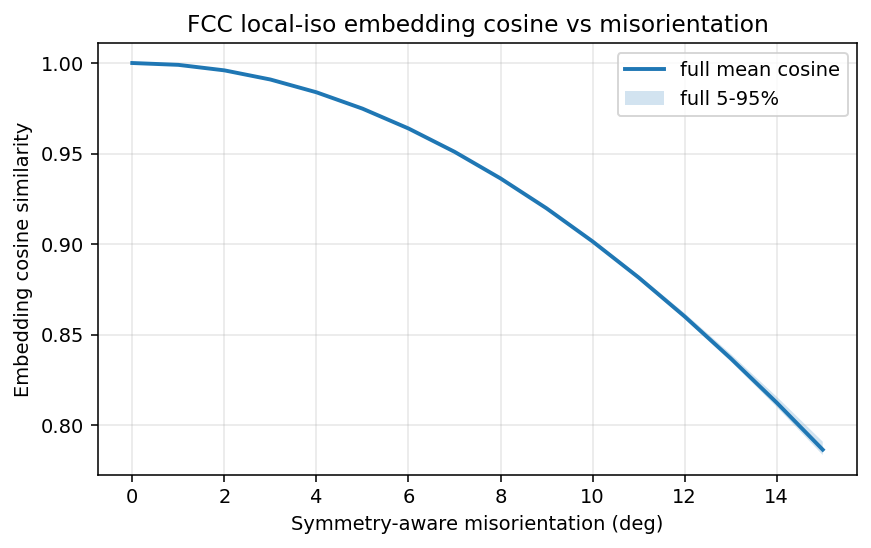

In [3]:
torch.manual_seed(0)

angles_deg = list(range(0, 16))
num_axes = 4000
q_ref = torch.tensor([[1.0, 0.0, 0.0, 0.0]], dtype=torch.float32)
feat_ref_full = encoder.forward_full(q_ref)
feat_ref_a1 = encoder.forward_a1(q_ref)

rows = []
for ang in angles_deg:
    axis = torch.randn(num_axes, 3)
    q = axis_angle_to_quat(
        axis,
        torch.full((num_axes,), math.radians(float(ang)), dtype=torch.float32),
    )
    q = _normalize_quaternions(q)
    mis_deg = _misorientation_angle_sym(q_ref.expand_as(q), q, sym_ops).rad2deg()
    feat_full = encoder.forward_full(q)
    feat_a1 = encoder.forward_a1(q)
    cos_full = F.cosine_similarity(feat_full, feat_ref_full.expand_as(feat_full), dim=-1)
    cos_a1 = F.cosine_similarity(feat_a1, feat_ref_a1.expand_as(feat_a1), dim=-1)
    rows.append({
        "angle_deg": float(ang),
        "mis_mean_deg": float(mis_deg.mean().item()),
        "cos_full_mean": float(cos_full.mean().item()),
        "cos_full_q05": float(cos_full.quantile(0.05).item()),
        "cos_full_q95": float(cos_full.quantile(0.95).item()),
        "cos_a1_mean": float(cos_a1.mean().item()),
    })

for row in rows:
    print(
        f"angle={row['angle_deg']:>4.0f} deg | "
        f"mis={row['mis_mean_deg']:.3f} deg | "
        f"cos_full={row['cos_full_mean']:.6f} "
        f"[{row['cos_full_q05']:.6f}, {row['cos_full_q95']:.6f}] | "
        f"cos_a1={row['cos_a1_mean']:.6f}"
    )

x = [r['mis_mean_deg'] for r in rows]
y = [r['cos_full_mean'] for r in rows]
y_lo = [r['cos_full_q05'] for r in rows]
y_hi = [r['cos_full_q95'] for r in rows]

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(x, y, label='full mean cosine', linewidth=2)
plt.fill_between(x, y_lo, y_hi, alpha=0.2, label='full 5-95%')
plt.xlabel('Symmetry-aware misorientation (deg)')
plt.ylabel('Embedding cosine similarity')
plt.title('FCC local-iso embedding cosine vs misorientation')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 2. Threshold lookup

This cell turns cosine thresholds into approximate misorientation cutoffs, using the mean full-feature cosine curve.

In [4]:
torch.manual_seed(1)

angles_deg = torch.arange(0, 31, dtype=torch.float32)
num_axes = 4096
q_ref = torch.tensor([[1.0, 0.0, 0.0, 0.0]], dtype=torch.float32)
feat_ref = encoder.forward_full(q_ref)

cos_means = []
for ang in angles_deg.tolist():
    axis = torch.randn(num_axes, 3)
    q = axis_angle_to_quat(
        axis,
        torch.full((num_axes,), math.radians(float(ang)), dtype=torch.float32),
    )
    q = _normalize_quaternions(q)
    feat = encoder.forward_full(q)
    cos = F.cosine_similarity(feat, feat_ref.expand_as(feat), dim=-1)
    cos_means.append(float(cos.mean().item()))

thresholds = [0.995, 0.99, 0.98, 0.97, 0.95, 0.93, 0.90, 0.85, 0.80, 0.75]
lookup = []
for thr in thresholds:
    angle_hit = None
    for ang, cos_val in zip(angles_deg.tolist(), cos_means):
        if cos_val <= thr:
            angle_hit = ang
            break
    lookup.append((thr, angle_hit))

for thr, ang in lookup:
    print(f"cos >= {thr:.3f}  -> roughly <= {ang:.0f} deg")

cos >= 0.995  -> roughly <= 3 deg
cos >= 0.990  -> roughly <= 4 deg
cos >= 0.980  -> roughly <= 5 deg
cos >= 0.970  -> roughly <= 6 deg
cos >= 0.950  -> roughly <= 8 deg
cos >= 0.930  -> roughly <= 9 deg
cos >= 0.900  -> roughly <= 11 deg
cos >= 0.850  -> roughly <= 13 deg
cos >= 0.800  -> roughly <= 15 deg
cos >= 0.750  -> roughly <= 17 deg


## 3. Random-pair sanity check

The fixed-reference sweep is the cleanest way to build a lookup.

This random-pair check is here to confirm that pairwise cosine distributions stay well ordered when binned by symmetry-aware misorientation.

In [5]:
torch.manual_seed(2)

num_pairs = 20000
q1 = _normalize_quaternions(torch.randn(num_pairs, 4))
q2 = _normalize_quaternions(torch.randn(num_pairs, 4))
mis_deg = _misorientation_angle_sym(q1, q2, sym_ops).rad2deg()
feat1 = encoder.forward_full(q1)
feat2 = encoder.forward_full(q2)
cos = F.cosine_similarity(feat1, feat2, dim=-1)

bins = [(0, 2), (2, 3), (3, 5), (5, 7), (7, 10), (10, 15), (15, 20)]
for lo, hi in bins:
    mask = (mis_deg >= lo) & (mis_deg < hi)
    if int(mask.sum()) == 0:
        continue
    vals = cos[mask]
    print(
        f"bin [{lo:>2}, {hi:>2}) deg | count={int(mask.sum()):>5} | "
        f"mean={vals.mean().item():.6f} | q05={vals.quantile(0.05).item():.6f} | q95={vals.quantile(0.95).item():.6f}"
    )

bin [ 2,  3) deg | count=    4 | mean=0.993730 | q05=0.992422 | q95=0.995274
bin [ 3,  5) deg | count=    8 | mean=0.979864 | q05=0.976499 | q95=0.984662
bin [ 5,  7) deg | count=   33 | mean=0.962226 | q05=0.951750 | q95=0.973175
bin [ 7, 10) deg | count=  103 | mean=0.922560 | q05=0.903769 | q95=0.946158
bin [10, 15) deg | count=  293 | mean=0.840705 | q05=0.791577 | q95=0.895339
bin [15, 20) deg | count=  601 | mean=0.707614 | q05=0.644816 | q95=0.776074


## 4. Interpretation for OCRP / HR-conv masking

If the goal is to avoid boundary leakage while still permitting strong same-orientation mixing, a simple rule is:

1. Normalize the HR or LR feature vectors.
2. Compute cosine similarity to the center feature.
3. Keep only neighbors whose cosine exceeds a cutoff.
4. Renormalize the surviving weights.

A practical FCC starting point from this notebook:
- `cos >= 0.99` for a strict mask, about `<= 4 deg`
- `cos >= 0.98` for a moderate mask, about `<= 5 deg`
- `cos >= 0.97` for a looser mask, about `<= 6 deg`

If the current OCRP HR refinement is still blurring across boundaries, start with `0.98` or `0.99` before moving looser.

Important caveat:
- these cutoffs were measured on the FCC local-iso embedding and are most directly justified for the `forward_full` feature space used by OCRP.
- if you switch irreps or add more pre/post feature transforms, rerun this notebook and rebuild the lookup.